# 1. Understanding Data

* **Business Goal:** Predict students' final grade (G3) based on their personal, family, and academic background, in order to identify at-risk students early and enable targeted academic support
* **Features:** school ID, gender, age, size of family, Father education, Mother education, Occupation of Father and Mother, Family Relation, Health, Grades

# 2. Load and Inspect

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv("/content/sample_data/student_data.csv")
df.head()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10


In [ ]:
df.shape

(395, 33)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (total 33 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   school      395 non-null    object
 1   sex         395 non-null    object
 2   age         395 non-null    int64 
 3   address     395 non-null    object
 4   famsize     395 non-null    object
 5   Pstatus     395 non-null    object
 6   Medu        395 non-null    int64 
 7   Fedu        395 non-null    int64 
 8   Mjob        395 non-null    object
 9   Fjob        395 non-null    object
 10  reason      395 non-null    object
 11  guardian    395 non-null    object
 12  traveltime  395 non-null    int64 
 13  studytime   395 non-null    int64 
 14  failures    395 non-null    int64 
 15  schoolsup   395 non-null    object
 16  famsup      395 non-null    object
 17  paid        395 non-null    object
 18  activities  395 non-null    object
 19  nursery     395 non-null    object
 20  higher    

In [ ]:
df.describe()

,age,Medu,Fedu,traveltime,studytime,failures,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
count,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000
mean,16.696203,2.749367,2.521519,1.448101,2.035443,0.334177,3.944304,3.235443,3.108861,1.481013,2.291139,3.554430,5.708861,10.908861,10.713924,10.415190
std,1.276043,1.094735,1.088201,0.697505,0.839240,0.743651,0.896659,0.998862,1.113278,0.890741,1.287897,1.390303,8.003096,3.319195,3.761505,4.581443
min,15.000000,0.000000,0.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,3.000000,0.000000,0.000000
25%,16.000000,2.000000,2.000000,1.000000,1.000000,0.000000,4.000000,3.000000,2.000000,1.000000,1.000000,3.000000,0.000000,8.000000,9.000000,8.000000
50%,17.000000,3.000000,2.000000,1.000000,2.000000,0.000000,4.000000,3.000000,3.000000,1.000000,2.000000,4.000000,4.000000,11.000000,11.000000,11.000000
75%,18.000000,4.000000,3.000000,2.000000,2.000000,0.000000,5.000000,4.000000,4.000000,2.000000,3.000000,5.000000,8.000000,13.000000,13.000000,14.000000
max,22.000000,4.000000,4.000000,4.000000,4.000000,3.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,75.000000,19.000000,19.000000,20.000000


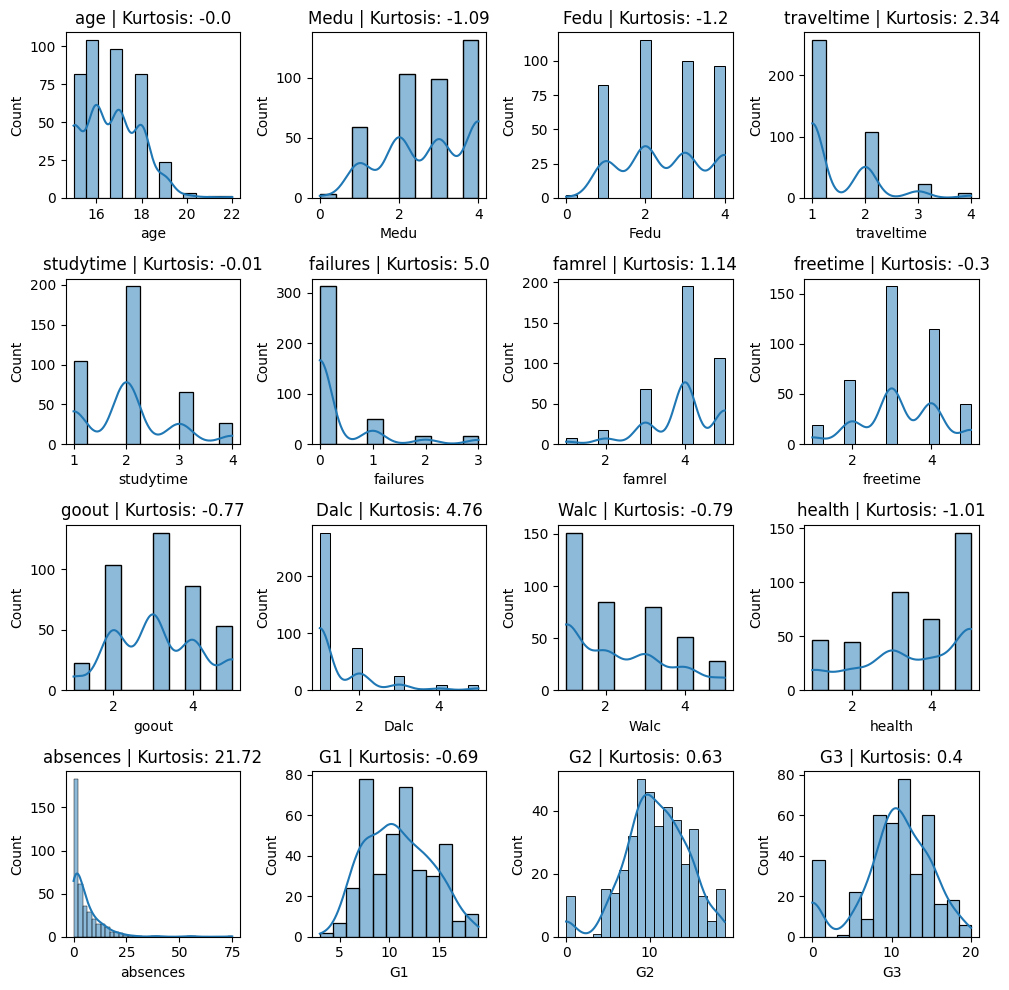

In [ ]:
import seaborn as sns

numerical = df.select_dtypes(include='number').columns.tolist()

fig, axes = plt.subplots(nrows= 4, ncols= 4, figsize=(10, 10))
axes = axes.flatten()

for i , col in enumerate(numerical):
    kurt = df[col].kurt().round(2)
    sns.histplot(df[col], ax=axes[i], kde=True)
    axes[i].set_title(f"{col} | Kurtosis: {kurt}")

plt.tight_layout()
plt.show()

**Most Outliers are most likely to be in absences**

# 3. Outliers Detection and Handling

In [ ]:
numerical = df.select_dtypes(include='number').columns
Q1 = df[numerical].quantile(0.25)
Q3 = df[numerical].quantile(0.75)
IQR = Q3 - Q1

outliers = ((df[numerical] < Q1 - 1.5 * IQR) | (df[numerical] > Q3 + 1.5 * IQR))
outliers.sum()

,0
age,1
Medu,0
Fedu,2
traveltime,8
studytime,27
failures,83
famrel,26
freetime,19
goout,0
Dalc,18


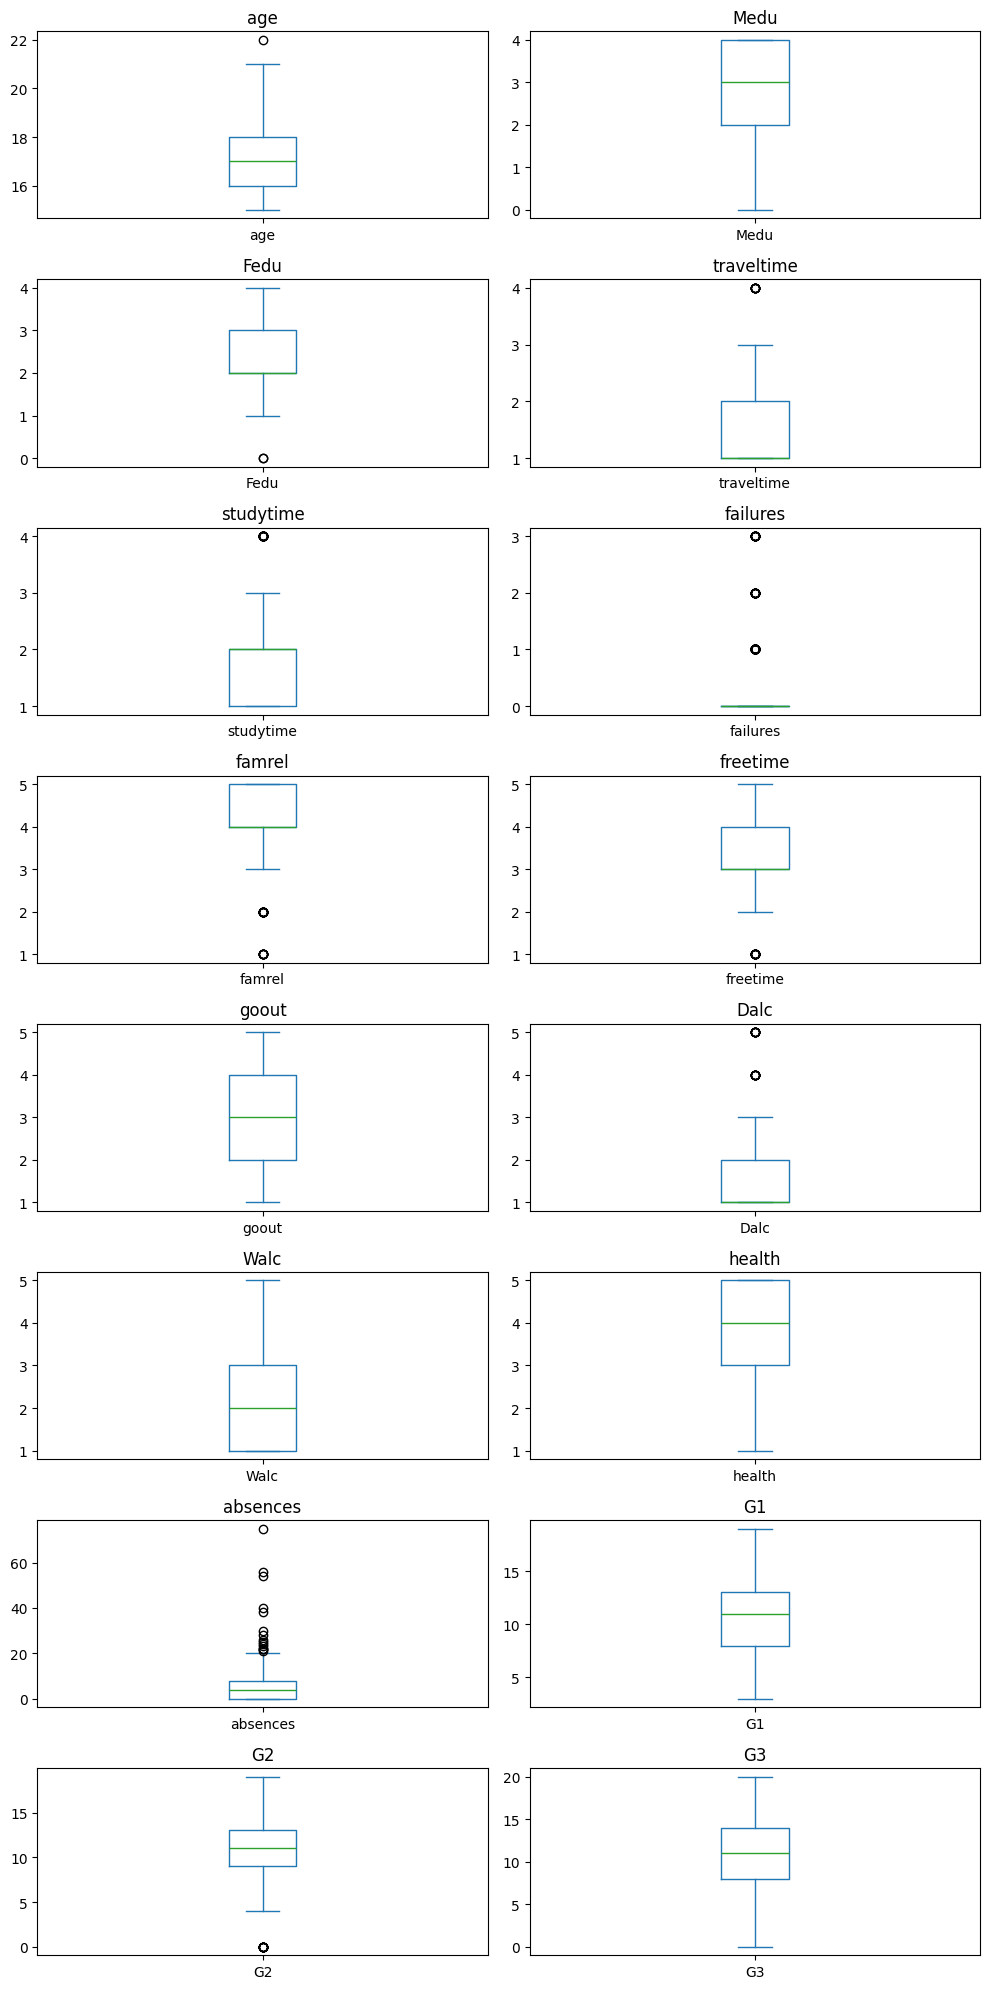

In [ ]:
numerical = df.select_dtypes(include='number').columns.tolist()
fig, axes = plt.subplots(nrows= 8, ncols= 2, figsize=(10, 20))
axes = axes.flatten()

for i , col in enumerate(numerical):
    df[col].plot(kind= 'box', ax= axes[i], title= col)

plt.tight_layout()
plt.show()

In [ ]:
outliers = [
            'age', 'Medu', 'Fedu', 'traveltime', 'studytime', 'failures',
            'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health',
            'absences', 'G1', 'G2', 'G3'
           ]

for col in outliers:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    df[col] = df[col].clip(lower= lower, upper= upper)

**Check NOW**

In [ ]:
for col in outliers:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    n = ((df[col] < lower) | (df[col] > upper)).sum()
    print(f"{col}: {n}")

age: 0
Medu: 0
Fedu: 0
traveltime: 0
studytime: 0
failures: 0
famrel: 0
freetime: 0
goout: 0
Dalc: 0
Walc: 0
health: 0
absences: 0
G1: 0
G2: 0
G3: 0


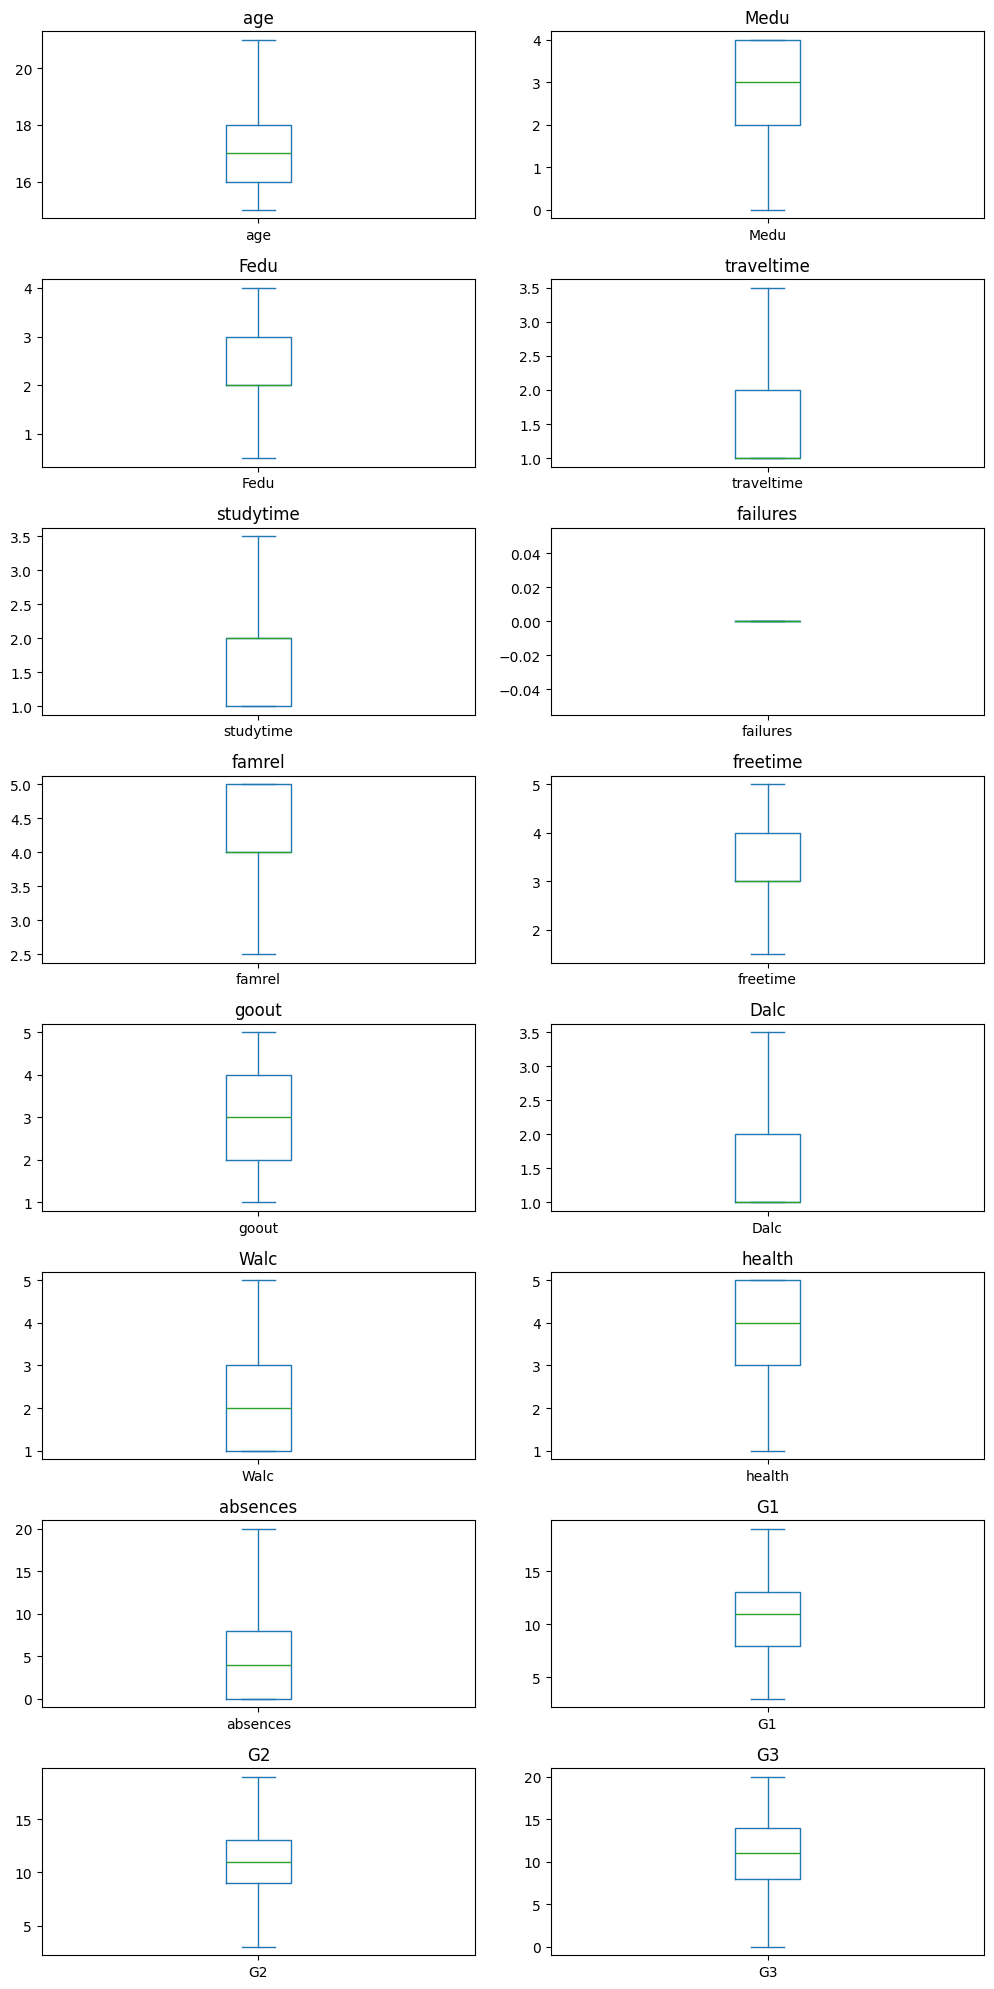

In [ ]:
numerical = df.select_dtypes(include='number').columns.tolist()
fig, axes = plt.subplots(nrows= 8, ncols= 2, figsize=(10, 20))
axes = axes.flatten()

for i , col in enumerate(numerical):
    df[col].plot(kind= 'box', ax= axes[i], title= col)

plt.tight_layout()
plt.show()

**No More Outliers!!**

# 4. Correlation Analysis

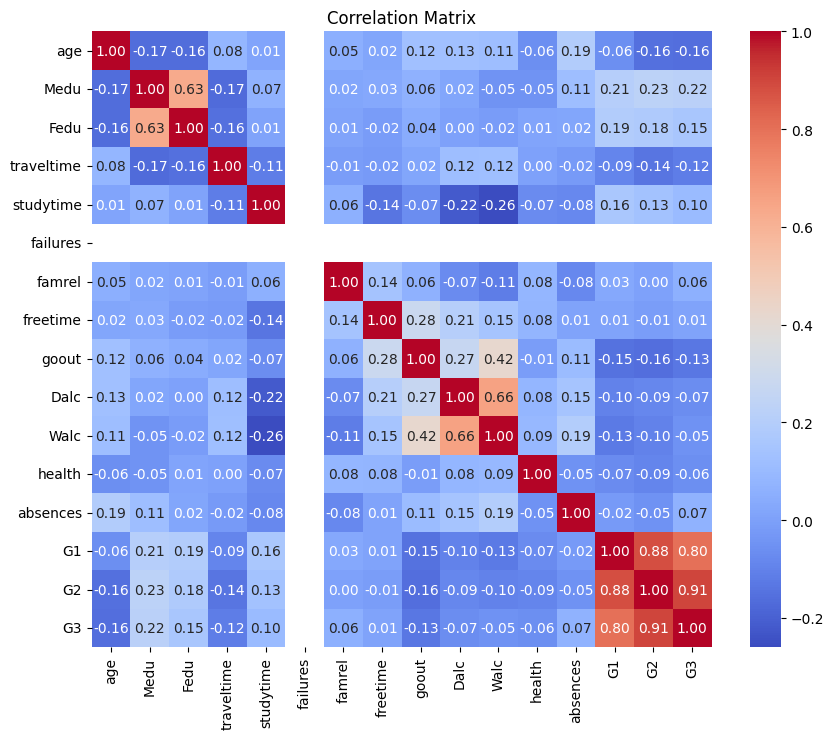

In [ ]:
plt.figure(figsize=(10, 8))
sns.heatmap(df[numerical].corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

**G1 and G2 show strong correlation with G3. Therefore we can conlude that students who perform well in earlier exams are more likely to get high grades in the final exam. This indicates that early academic performance is a strong predictor of the final outcome**

# 5. Classes Analysis

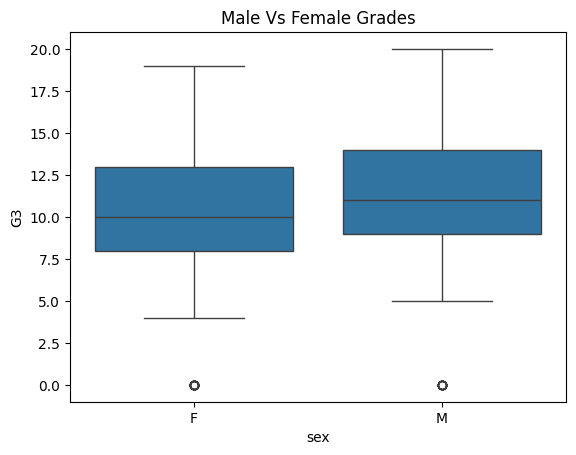

In [ ]:
sns.boxplot(x= 'sex', y= 'G3', data= df)
plt.title('Male Vs Female Grades')
plt.show()

**Male students tend to perform slightly better on average in G3 grades compared to female students, though the difference is not dramatic and both groups show similar variability in performance.**

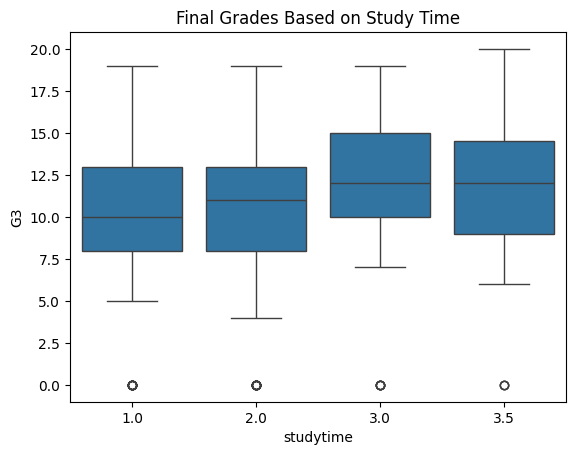

In [ ]:
sns.boxplot(x= 'studytime', y= 'G3', data= df)
plt.title('Final Grades Based on Study Time')
plt.show()

**Students with more studytime got higher grades**

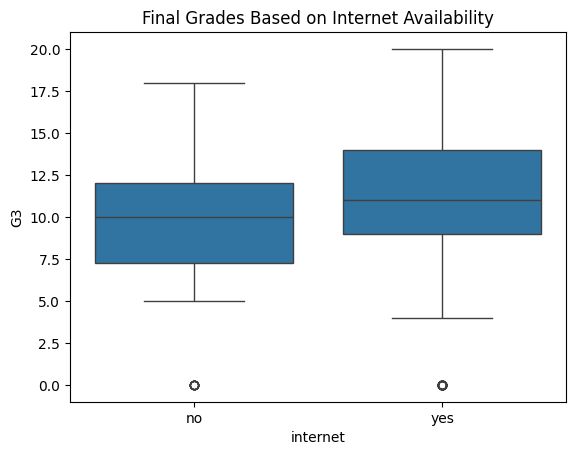

In [ ]:
sns.boxplot(x= 'internet', y= 'G3', data= df)
plt.title('Final Grades Based on Internet Availability')
plt.show()


**Students who have internet access tend to achieve slightly higher final grades on average.This may suggest that access to online resources can support better learning.**


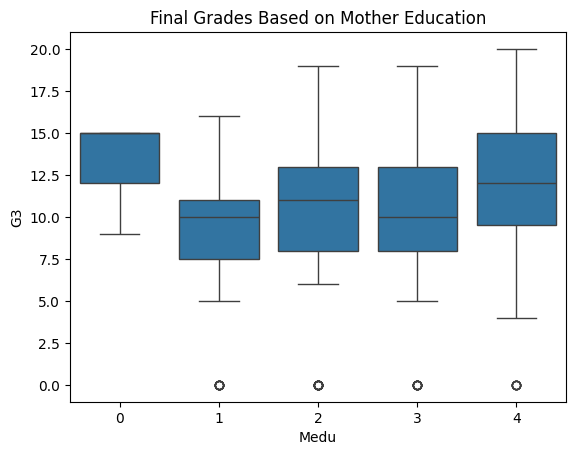

In [ ]:
sns.boxplot(x= 'Medu', y= 'G3', data= df)
plt.title('Final Grades Based on Mother Education')
plt.show()

**Students with higher Mother education tend to achieve better grades on average in comparison with Father education which shows less relationship with the students grades. This shows that parental education plays a role in academic support especially marental education**

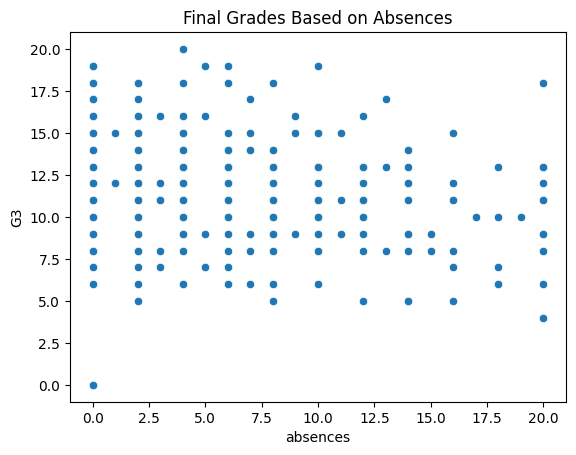

In [ ]:
sns.scatterplot(x= 'absences', y= 'G3', data= df)
plt.title('Final Grades Based on Absences')
plt.show()

**While absences show a slight negative trend with final grades, the correlation is too weak and scattered to be a reliable predictor. Students across all absence levels achieved similar grade ranges, indicating attendance alone does not determine academic success.**

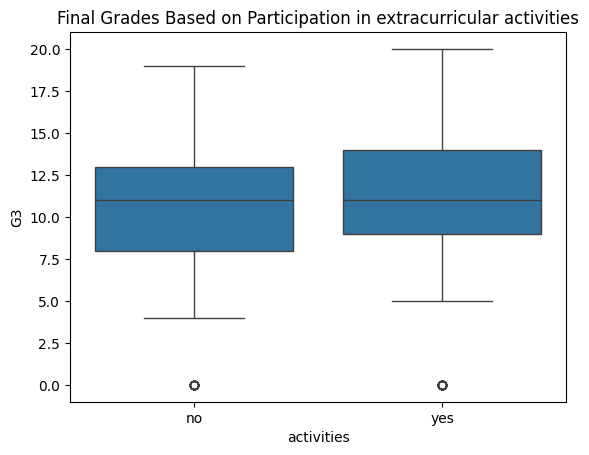

In [ ]:
sns.boxplot(x= 'activities', y= 'G3', data= df)
plt.title('Final Grades Based on Participation in extracurricular activities')
plt.show()

**Participation in extracurricular activities has no significant effect on final grades, as both groups show nearly identical median scores and distributions. This suggests that engaging in extra activities neither helps nor hinders academic performance in this dataset.**

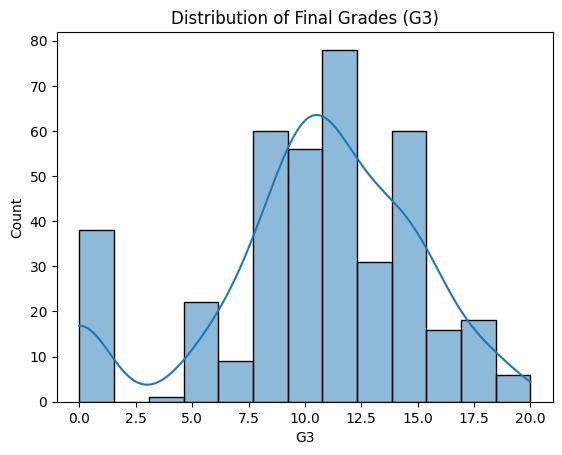

In [ ]:
sns.histplot(df['G3'], kde=True)
plt.title('Distribution of Final Grades (G3)')
plt.show()

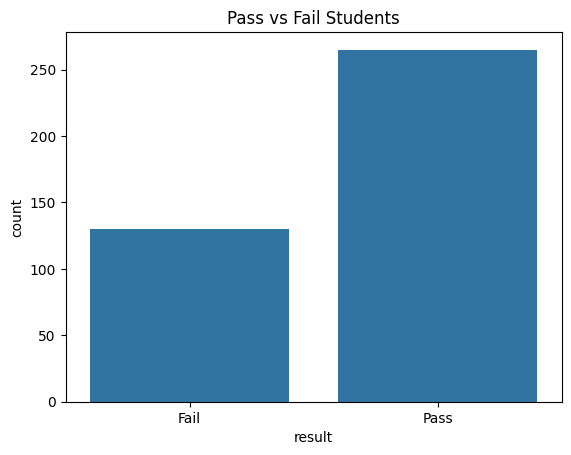

In [ ]:
df['result'] = df['G3'].apply(lambda x: 'Pass' if x >= 10 else 'Fail')
sns.countplot(x='result', data=df)
plt.title('Pass vs Fail Students')
plt.show()

# 6. Preprocessing

In [ ]:
# Splitting
from sklearn.model_selection import train_test_split

df['result'] = df['G3'].apply(lambda x: 'Pass' if x >= 10 else 'Fail')
# Convert all categorical variables → numerical
X = pd.get_dummies(df.drop(['G1','G2','G3', 'result'], axis=1), drop_first=True)
y = df['result']

X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size= 0.2, random_state= 42)

X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size= 0.25, random_state= 42)

print(f"Train Size:            {X_train.shape}")
print(f"Validation Size:       {X_val.shape}")
print(f"Test Size:             {X_test.shape}")

Train Size:            (237, 39)
Validation Size:       (79, 39)
Test Size:             (79, 39)


In [ ]:
# Scaling

from sklearn.preprocessing import StandardScaler

# We don't need this anymore as we converted all features into numeric features
# numerics = X.select_dtypes(include=np.number).columns

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

print(f"Train mean: {X_train_scaled.mean().round(1)}")
print(f"Train std:  {X_train_scaled.std().round(1)}")

Train mean: 0.0
Train std:  1.0


In [ ]:
print(f"X_train_scaled shape: {X_train_scaled.shape}")
print(f"X_val_scaled shape:   {X_val_scaled.shape}")
print(f"X_test_scaled shape:  {X_test_scaled.shape}")
print(f"y_train shape:        {y_train.shape}")
print(f"y_val shape:          {y_val.shape}")
print(f"y_test shape:         {y_test.shape}")


X_train_scaled shape: (237, 39)
X_val_scaled shape:   (79, 39)
X_test_scaled shape:  (79, 39)
y_train shape:        (237,)
y_val shape:          (79,)
y_test shape:         (79,)


In [ ]:
x_train_scaled_df = pd.DataFrame(X_train_scaled, columns=X_train.columns)

x_train_scaled_df.describe().round(2)

,age,Medu,Fedu,traveltime,studytime,failures,famrel,freetime,goout,Dalc,...,guardian_mother,guardian_other,schoolsup_yes,famsup_yes,paid_yes,activities_yes,nursery_yes,higher_yes,internet_yes,romantic_yes
count,237.00,237.00,237.00,237.00,237.00,237.0,237.00,237.00,237.00,237.00,...,237.00,237.00,237.00,237.00,237.00,237.0,237.00,237.00,237.00,237.00
mean,0.00,0.00,0.00,-0.00,0.00,0.0,-0.00,0.00,-0.00,-0.00,...,-0.00,-0.00,-0.00,0.00,-0.00,0.0,0.00,-0.00,0.00,0.00
std,1.00,1.00,1.00,1.00,1.00,0.0,1.00,1.00,1.00,1.00,...,1.00,1.00,1.00,1.00,1.00,1.0,1.00,1.00,1.00,1.00
min,-1.48,-2.57,-1.91,-0.66,-1.37,0.0,-1.92,-1.82,-1.90,-0.57,...,-1.46,-0.32,-0.36,-1.23,-0.88,-1.0,-1.89,-3.72,-2.36,-0.75
25%,-0.65,-0.68,-0.51,-0.66,-0.03,0.0,-0.01,-0.26,-1.02,-0.57,...,-1.46,-0.32,-0.36,-1.23,-0.88,-1.0,0.53,0.27,0.42,-0.75
50%,0.19,0.26,0.43,-0.66,-0.03,0.0,-0.01,-0.26,-0.14,-0.57,...,0.69,-0.32,-0.36,0.81,-0.88,1.0,0.53,0.27,0.42,-0.75
75%,1.02,1.20,0.43,0.81,-0.03,0.0,1.27,0.77,0.74,0.79,...,0.69,-0.32,-0.36,0.81,1.14,1.0,0.53,0.27,0.42,1.33
max,2.69,1.20,1.36,3.01,1.97,0.0,1.27,1.81,1.62,2.84,...,0.69,3.13,2.79,0.81,1.14,1.0,0.53,0.27,0.42,1.33


In [ ]:
# Save splits as csv files
pd.DataFrame(X_train_scaled, columns=X_train.columns).assign(Outcome=y_train.values).to_csv('train.csv', index=False)
pd.DataFrame(X_val_scaled,   columns=X_train.columns).assign(Outcome=y_val.values).to_csv('val.csv',   index=False)
pd.DataFrame(X_test_scaled,  columns=X_train.columns).assign(Outcome=y_test.values).to_csv('test.csv',  index=False)

print("Saved: train.csv, val.csv, test.csv with G3 as target")

Saved: train.csv, val.csv, test.csv with G3 as target


In [ ]:
x_train_scaled_df.head()

,age,Medu,Fedu,traveltime,studytime,failures,famrel,freetime,goout,Dalc,...,guardian_mother,guardian_other,schoolsup_yes,famsup_yes,paid_yes,activities_yes,nursery_yes,higher_yes,internet_yes,romantic_yes
0,1.019888,0.258311,0.428459,-0.663624,-0.031023,0.0,1.269325,-0.264770,0.743613,-0.573570,...,0.687059,-0.319884,-0.358569,-1.233400,-0.876731,0.995789,0.530171,0.269069,0.423207,-0.754676
1,0.186393,-0.683531,1.364356,-0.663624,1.305775,0.0,-0.008085,0.772427,-0.137568,-0.573570,...,-1.455480,-0.319884,-0.358569,0.810767,-0.876731,-1.004228,0.530171,0.269069,0.423207,1.325071
2,1.019888,-1.625372,0.428459,-0.663624,-1.367821,0.0,-0.008085,-0.264770,-0.137568,0.792622,...,0.687059,-0.319884,-0.358569,-1.233400,-0.876731,-1.004228,0.530171,-3.716517,0.423207,1.325071
3,1.853383,1.200153,1.364356,0.806272,-0.031023,0.0,-1.924200,-0.264770,0.743613,0.792622,...,-1.455480,3.126136,-0.358569,0.810767,1.140601,0.995789,0.530171,0.269069,0.423207,-0.754676
4,0.186393,1.200153,1.364356,-0.663624,-0.031023,0.0,1.269325,-0.264770,1.624794,2.841912,...,0.687059,-0.319884,-0.358569,0.810767,1.140601,-1.004228,0.530171,0.269069,0.423207,1.325071


In [ ]:
print(X.columns.tolist())

['age', 'Medu', 'Fedu', 'traveltime', 'studytime', 'failures', 'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health', 'absences', 'school_MS', 'sex_M', 'address_U', 'famsize_LE3', 'Pstatus_T', 'Mjob_health', 'Mjob_other', 'Mjob_services', 'Mjob_teacher', 'Fjob_health', 'Fjob_other', 'Fjob_services', 'Fjob_teacher', 'reason_home', 'reason_other', 'reason_reputation', 'guardian_mother', 'guardian_other', 'schoolsup_yes', 'famsup_yes', 'paid_yes', 'activities_yes', 'nursery_yes', 'higher_yes', 'internet_yes', 'romantic_yes']


#  7. Model Evaluation Setup

To ensure a fair comparison between different machine learning models, we define a **unified evaluation function**.  
This function trains each model and evaluates it using the same set of metrics: Accuracy, Precision, Recall, and F1-score.

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# unified evaluation function
def evaluate_model(model, X_train, y_train, X_val, y_val, model_name):
    # Train
    model.fit(X_train, y_train)

    # Predict
    y_pred = model.predict(X_val)

    # Metrics
    acc = accuracy_score(y_val, y_pred)
    prec = precision_score(y_val, y_pred, pos_label='Pass')
    rec = recall_score(y_val, y_pred, pos_label='Pass')
    f1 = f1_score(y_val, y_pred, pos_label='Pass')

    # Print results
    print(f"--- {model_name} ---")
    print(f"Accuracy:  {acc* 100:.2f}%")
    print(f"Precision: {prec* 100:.2f}%")
    print(f"Recall:    {rec* 100:.2f}%")
    print(f"F1-score:  {f1* 100:.2f}%")

    return acc, prec, rec, f1

# 8. Logistic Regression Model

In [ ]:
from sklearn.linear_model import LogisticRegression

# Initialize model
log_reg = LogisticRegression(max_iter=1000)

# Evaluate using SCALED data
log_reg_results = evaluate_model(
    log_reg,
    X_train_scaled, y_train,
    X_val_scaled, y_val,
    "Logistic Regression"
)

--- Logistic Regression ---
Accuracy:  63.29%
Precision: 66.13%
Recall:    83.67%
F1-score:  73.87%


# 9. K-Nearest Neighbors (KNN)

In [ ]:
from sklearn.neighbors import KNeighborsClassifier

# Initialize model
knn = KNeighborsClassifier(n_neighbors=5)

# Evaluate using SCALED data
knn_results = evaluate_model(
    knn,
    X_train_scaled, y_train,
    X_val_scaled, y_val,
    "KNN"
)

--- KNN ---
Accuracy:  64.56%
Precision: 66.15%
Recall:    87.76%
F1-score:  75.44%


KNN slightly outperformed Logistic Regression because it can model non-linear relationships by looking at nearby data points, while Logistic Regression is limited to a linear decision boundary.

# 10. Naive Bayes Model

In [ ]:
from sklearn.naive_bayes import GaussianNB

# Initialize model
nb = GaussianNB()

# Use NON-SCALED data
nb_results = evaluate_model(
    nb,
    X_train, y_train,
    X_val, y_val,
    "Naive Bayes"
)

--- Naive Bayes ---
Accuracy:  65.82%
Precision: 68.33%
Recall:    83.67%
F1-score:  75.23%


# 11. Decision Tree Model

In [ ]:
from sklearn.tree import DecisionTreeClassifier

# Initialize model
dt = DecisionTreeClassifier(max_depth=5, random_state=42)

# Use NON-SCALED data
dt_results = evaluate_model(
    dt,
    X_train, y_train,
    X_val, y_val,
    "Decision Tree"
)

--- Decision Tree ---
Accuracy:  64.56%
Precision: 66.67%
Recall:    85.71%
F1-score:  75.00%


## Model Comparison

| Model                | Accuracy (%) | Precision (%) | Recall (%) | F1-score (%) |
|---------------------|-------------|--------------|-----------|-------------|
| Logistic Regression | 63.29       | 66.13        | 83.67     | 73.87       |
| KNN                 | 64.56       | 66.15        | **87.76** | **75.44**   |
| Naive Bayes         | **65.82**   | **68.33**    | 83.67     | 75.23       |
| Decision Tree       | 64.56       | 66.67        | 85.71     | 75.00       |

All models achieved similar overall performance, with accuracy ranging between 63% and 66%. This indicates that the dataset does not strongly favor a specific type of model and does not contain highly complex patterns.

KNN achieved the highest recall, making it effective at identifying students who are likely to pass, while Naive Bayes achieved the highest precision, reducing incorrect “Pass” predictions. Decision Tree provided a balanced performance by capturing feature interactions, and Logistic Regression performed slightly worse due to its assumption of linear relationships.

Overall, Naive Bayes achieved the highest accuracy, while KNN achieved the best F1-score, making them the strongest models in this comparison. The similarity in performance suggests that the dataset is relatively simple and does not require highly complex models to achieve good results.